# 02 — Dense vs Sparse Encoding

## From the AWS Slide Deck: Two Flavours of Semantic Search

| | Dense Encoding | Sparse Encoding |
|---|---|---|
| **Vector shape** | Fixed-length, all dims non-zero (e.g. 1024) | Very high-dim, ~1% non-zero |
| **Semantics** | Deep — encodes full meaning into geometry | Weighted synonym expansion on top of keywords |
| **Index type** | HNSW vector index | Inverted index (Lucene-native) |
| **RAM cost** | High — every vector lives in memory | ~0 RAM overhead at query time |
| **Index size** | Large | 10× smaller than dense |
| **Interpretability** | Black box | Fully interpretable (explain API) |
| **Best for** | RAG, cross-lingual, nuanced similarity | Speed-critical, cost-sensitive, mixed keyword+semantic |

This notebook implements **both** with real Bedrock API calls and Qdrant, then compares them.

## Step 1 — Install & Import

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
    'boto3', 'qdrant-client', 'scikit-learn', 'numpy', 'matplotlib', 'seaborn', 'python-dotenv'])
print('Packages ready.')

Packages ready.


In [2]:
from dotenv import load_dotenv
load_dotenv('../../../.env')

import os, json, time, uuid
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import boto3
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct,
    SparseVector, SparseVectorParams, SparseIndexParams
)

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27', 'axes.edgecolor': '#3a3d4d',
    'axes.labelcolor': '#e0e0e0', 'xtick.color': '#a0a0b0',
    'ytick.color': '#a0a0b0', 'text.color': '#e0e0e0',
    'grid.color': '#2a2d3d', 'grid.linestyle': '--', 'grid.alpha': 0.5,
    'axes.titlesize': 12, 'axes.labelsize': 10,
})
print('Imports OK')

Imports OK


## Step 2 — Configuration

In [3]:
AWS_REGION      = os.getenv('AWS_DEFAULT_REGION', 'us-east-1')
EMBEDDING_MODEL = 'amazon.titan-embed-text-v2:0'
EMBEDDING_DIM   = 1024
QDRANT_URL      = os.getenv('QDRANT_URL', '')
QDRANT_API_KEY  = os.getenv('QDRANT_API_KEY', '')

bedrock_rt = boto3.client('bedrock-runtime', region_name=AWS_REGION)

def embed(text: str) -> np.ndarray:
    body = json.dumps({'inputText': text, 'dimensions': EMBEDDING_DIM, 'normalize': True})
    resp = bedrock_rt.invoke_model(
        modelId=EMBEDDING_MODEL, body=body,
        contentType='application/json', accept='application/json'
    )
    return np.array(json.loads(resp['body'].read())['embedding'], dtype=np.float32)

def embed_batch(texts, delay=0.05):
    vecs = []
    for i, t in enumerate(texts):
        vecs.append(embed(t))
        time.sleep(delay)
        if (i + 1) % 10 == 0:
            print(f'  Embedded {i+1}/{len(texts)}')
    return np.vstack(vecs)

# Qdrant client
if QDRANT_URL:
    kw = {'url': QDRANT_URL}
    if QDRANT_API_KEY:
        kw['api_key'] = QDRANT_API_KEY
    qc = QdrantClient(**kw)
    print(f'Qdrant Cloud: {QDRANT_URL}')
else:
    qc = QdrantClient(':memory:')
    print('Qdrant in-memory')

# Smoke test
v = embed('hello world')
print(f'Embedding dim={v.shape[0]}, norm={np.linalg.norm(v):.4f}')

Qdrant in-memory


Embedding dim=1024, norm=1.0000


## Step 3 — Corpus (25 sentences, 5 topics)

In [4]:
topic_sentences = {
    'Space & Astronomy': [
        'The Milky Way is a spiral galaxy.',
        'Black holes have enormous gravitational pull.',
        'NASA launched the James Webb Space Telescope.',
        'Mars has two small moons, Phobos and Deimos.',
        'Neutron stars are incredibly dense stellar remnants.',
    ],
    'Cooking & Food': [
        'Pasta is best cooked al dente.',
        'Sauteing garlic in olive oil adds depth of flavour.',
        'Fermentation is used to make bread and beer.',
        'Fresh herbs brighten any dish.',
        'Umami is often called the fifth taste.',
    ],
    'Machine Learning': [
        'Gradient descent optimises neural network weights.',
        'Overfitting occurs when a model memorises training data.',
        'Transformers use self-attention mechanisms.',
        'Regularisation prevents overfitting in ML models.',
        'Backpropagation computes gradients for weight updates.',
    ],
    'Finance & Economics': [
        'Inflation erodes the purchasing power of money.',
        'Compound interest grows wealth exponentially.',
        'GDP measures the total economic output of a country.',
        'Diversification reduces investment portfolio risk.',
        'Central banks set interest rates to control inflation.',
    ],
    'Health & Medicine': [
        'Vaccines stimulate the immune system against pathogens.',
        'The heart pumps blood through the circulatory system.',
        'Antibiotics fight bacterial but not viral infections.',
        'Regular exercise reduces the risk of cardiovascular disease.',
        'The gut microbiome influences mental and physical health.',
    ],
}

sentences = [s for sents in topic_sentences.values() for s in sents]
labels    = [t for t, sents in topic_sentences.items() for _ in sents]
print(f'Corpus: {len(sentences)} sentences across {len(topic_sentences)} topics')

Corpus: 25 sentences across 5 topics


## Step 4 — Dense Encoding

> **Intuition:** Every dimension is non-zero. The model compresses the full meaning of a sentence into a fixed-length 1024-dim vector. Two semantically similar sentences will be geometrically close — even if they share zero words.

In [5]:
print('=== DENSE ENCODING (Bedrock Titan V2, 1024-dim) ===')
t0 = time.time()
dense_matrix = embed_batch(sentences)  # (25, 1024)
dense_time = time.time() - t0

# Sparsity = fraction of near-zero values
threshold = 1e-4
dense_sparsity = np.mean(np.abs(dense_matrix) < threshold) * 100
dense_norm_mean = float(np.mean(np.linalg.norm(dense_matrix, axis=1)))
dense_mem_bytes = dense_matrix.nbytes  # float32

print(f'Dimensions     : {dense_matrix.shape[1]}')
print(f'Sparsity       : {dense_sparsity:.2f}% near-zero (should be very low)')
print(f'Mean L2 norm   : {dense_norm_mean:.4f} (unit-normalised → ~1.0)')
print(f'Embed time     : {dense_time:.2f}s ({dense_time/len(sentences)*1000:.0f}ms/doc)')
print(f'Memory (float32): {dense_mem_bytes/1024:.1f} KB for {len(sentences)} docs')

=== DENSE ENCODING (Bedrock Titan V2, 1024-dim) ===


  Embedded 10/25


  Embedded 20/25


Dimensions     : 1024
Sparsity       : 0.29% near-zero (should be very low)
Mean L2 norm   : 1.0000 (unit-normalised → ~1.0)
Embed time     : 5.25s (210ms/doc)
Memory (float32): 100.0 KB for 25 docs


In [6]:
# Store in Qdrant dense collection
DENSE_COLL = 'dense_demo_02'
for c in qc.get_collections().collections:
    if c.name == DENSE_COLL:
        qc.delete_collection(DENSE_COLL)
        break

qc.create_collection(DENSE_COLL,
    vectors_config=VectorParams(size=EMBEDDING_DIM, distance=Distance.COSINE))

points = [
    PointStruct(
        id=str(uuid.uuid4()),
        vector=dense_matrix[i].tolist(),
        payload={'text': sentences[i], 'topic': labels[i]}
    ) for i in range(len(sentences))
]
qc.upsert(collection_name=DENSE_COLL, points=points)
print(f'Indexed {len(points)} docs into Qdrant dense collection.')

Indexed 25 docs into Qdrant dense collection.


## Step 5 — Sparse Encoding

> **Intuition:** The model expands a document with weighted synonyms and stores only the non-zero terms in an inverted index. `"car"` → `{automobile: 0.8, vehicle: 0.6, sedan: 0.4}`. The result is a 30,000-dim vector with ~1% non-zero — 10× smaller than dense. Zero RAM at query time because it uses the existing Lucene inverted index infrastructure.

In [7]:
print('=== SPARSE ENCODING (TF-IDF, vocab=500) ===')
SPARSE_DIM = 500

t0 = time.time()
tfidf = TfidfVectorizer(max_features=SPARSE_DIM, ngram_range=(1, 2), sublinear_tf=True)
sparse_matrix_csr = tfidf.fit_transform(sentences)  # scipy CSR sparse matrix
sparse_time = time.time() - t0

sparse_matrix_dense = sparse_matrix_csr.toarray().astype(np.float32)  # for comparison
sparse_sparsity = (1 - sparse_matrix_csr.nnz / (sparse_matrix_csr.shape[0] * sparse_matrix_csr.shape[1])) * 100
sparse_mem_bytes_approx = sparse_matrix_csr.nnz * (4 + 4)  # float32 value + int32 index per non-zero

print(f'Vocabulary size  : {len(tfidf.vocabulary_)} terms (= dimensions)')
print(f'Sparsity         : {sparse_sparsity:.2f}% zeros (should be very high)')
print(f'Non-zeros total  : {sparse_matrix_csr.nnz} ({sparse_matrix_csr.nnz/len(sentences):.1f} per doc)')
print(f'Build time       : {sparse_time*1000:.1f}ms (no API call needed)')
print(f'Approx mem       : {sparse_mem_bytes_approx/1024:.1f} KB (store only non-zeros)')
print()
# Show top terms for first sentence
idx = sparse_matrix_csr[0].nonzero()[1]
vals = sparse_matrix_csr[0, idx].toarray().flatten()
top = sorted(zip(tfidf.get_feature_names_out()[idx], vals), key=lambda x: -x[1])[:6]
print(f'Sentence: "{sentences[0]}"')
print(f'Top TF-IDF terms: {top}')

=== SPARSE ENCODING (TF-IDF, vocab=500) ===
Vocabulary size  : 290 terms (= dimensions)
Sparsity         : 95.67% zeros (should be very high)
Non-zeros total  : 314 (12.6 per doc)
Build time       : 5.7ms (no API call needed)
Approx mem       : 2.5 KB (store only non-zeros)

Sentence: "The Milky Way is a spiral galaxy."
Top TF-IDF terms: [('milky', np.float64(0.31857956491811307)), ('way', np.float64(0.31857956491811307)), ('spiral', np.float64(0.31857956491811307)), ('galaxy', np.float64(0.31857956491811307)), ('the milky', np.float64(0.31857956491811307)), ('milky way', np.float64(0.31857956491811307))]


In [8]:
# Store in Qdrant sparse collection
SPARSE_COLL = 'sparse_demo_02'
for c in qc.get_collections().collections:
    if c.name == SPARSE_COLL:
        qc.delete_collection(SPARSE_COLL)
        break

qc.create_collection(SPARSE_COLL,
    vectors_config={},  # no dense vectors
    sparse_vectors_config={
        'sparse': SparseVectorParams(index=SparseIndexParams(on_disk=False))
    }
)

sparse_points = []
for i in range(len(sentences)):
    row = sparse_matrix_csr[i]
    indices = row.nonzero()[1].tolist()
    values  = row.data.tolist()
    sparse_points.append(PointStruct(
        id=str(uuid.uuid4()),
        vector={'sparse': SparseVector(indices=indices, values=values)},
        payload={'text': sentences[i], 'topic': labels[i]}
    ))

qc.upsert(collection_name=SPARSE_COLL, points=sparse_points)
print(f'Indexed {len(sparse_points)} docs into Qdrant sparse collection.')

Indexed 25 docs into Qdrant sparse collection.


## Step 6 — Query Both Indexes and Compare

In [9]:
test_queries = [
    ('neural networks learning from data',   'Machine Learning'),
    ('stellar remnants after supernova',      'Space & Astronomy'),
    ('central bank borrowing costs',          'Finance & Economics'),
    ('gut bacteria and wellbeing',            'Health & Medicine'),
    ('cooking pasta garlic',                  'Cooking & Food'),
]

def dense_search(query, top_k=3):
    qvec = embed(query)
    hits = qc.query_points(DENSE_COLL, query=qvec.tolist(), limit=top_k, with_payload=True)
    return [(p.payload['text'], p.payload['topic'], float(p.score)) for p in hits.points]

def sparse_search(query, top_k=3):
    qvec = tfidf.transform([query])
    idx = qvec.nonzero()[1].tolist()
    vals = qvec.data.tolist()
    if not idx:
        return []
    hits = qc.query_points(
        SPARSE_COLL,
        query=SparseVector(indices=idx, values=vals),
        using='sparse',
        limit=top_k,
        with_payload=True
    )
    return [(p.payload['text'], p.payload['topic'], float(p.score)) for p in hits.points]

print('{:<45} {:<22} {:<22} {}'.format('Query', 'Dense top-1 topic', 'Sparse top-1 topic', 'Match?'))
print('-' * 100)
comparison_data = []
for q, expected in test_queries:
    d_res = dense_search(q)
    s_res = sparse_search(q)
    d_top = d_res[0][1] if d_res else 'N/A'
    s_top = s_res[0][1] if s_res else 'N/A'
    d_hit = '✓' if d_top == expected else '✗'
    s_hit = '✓' if s_top == expected else '✗'
    print(f'{q[:44]:<45} {d_top:<22} {s_top:<22} D:{d_hit} S:{s_hit}')
    comparison_data.append((q, expected, d_res, s_res, d_hit, s_hit))

Query                                         Dense top-1 topic      Sparse top-1 topic     Match?
----------------------------------------------------------------------------------------------------


neural networks learning from data            Machine Learning       Machine Learning       D:✓ S:✓


stellar remnants after supernova              Space & Astronomy      Space & Astronomy      D:✓ S:✓


central bank borrowing costs                  Finance & Economics    Finance & Economics    D:✓ S:✓


gut bacteria and wellbeing                    Health & Medicine      Health & Medicine      D:✓ S:✓


cooking pasta garlic                          Cooking & Food         Cooking & Food         D:✓ S:✓


## Step 7 — Visualizations

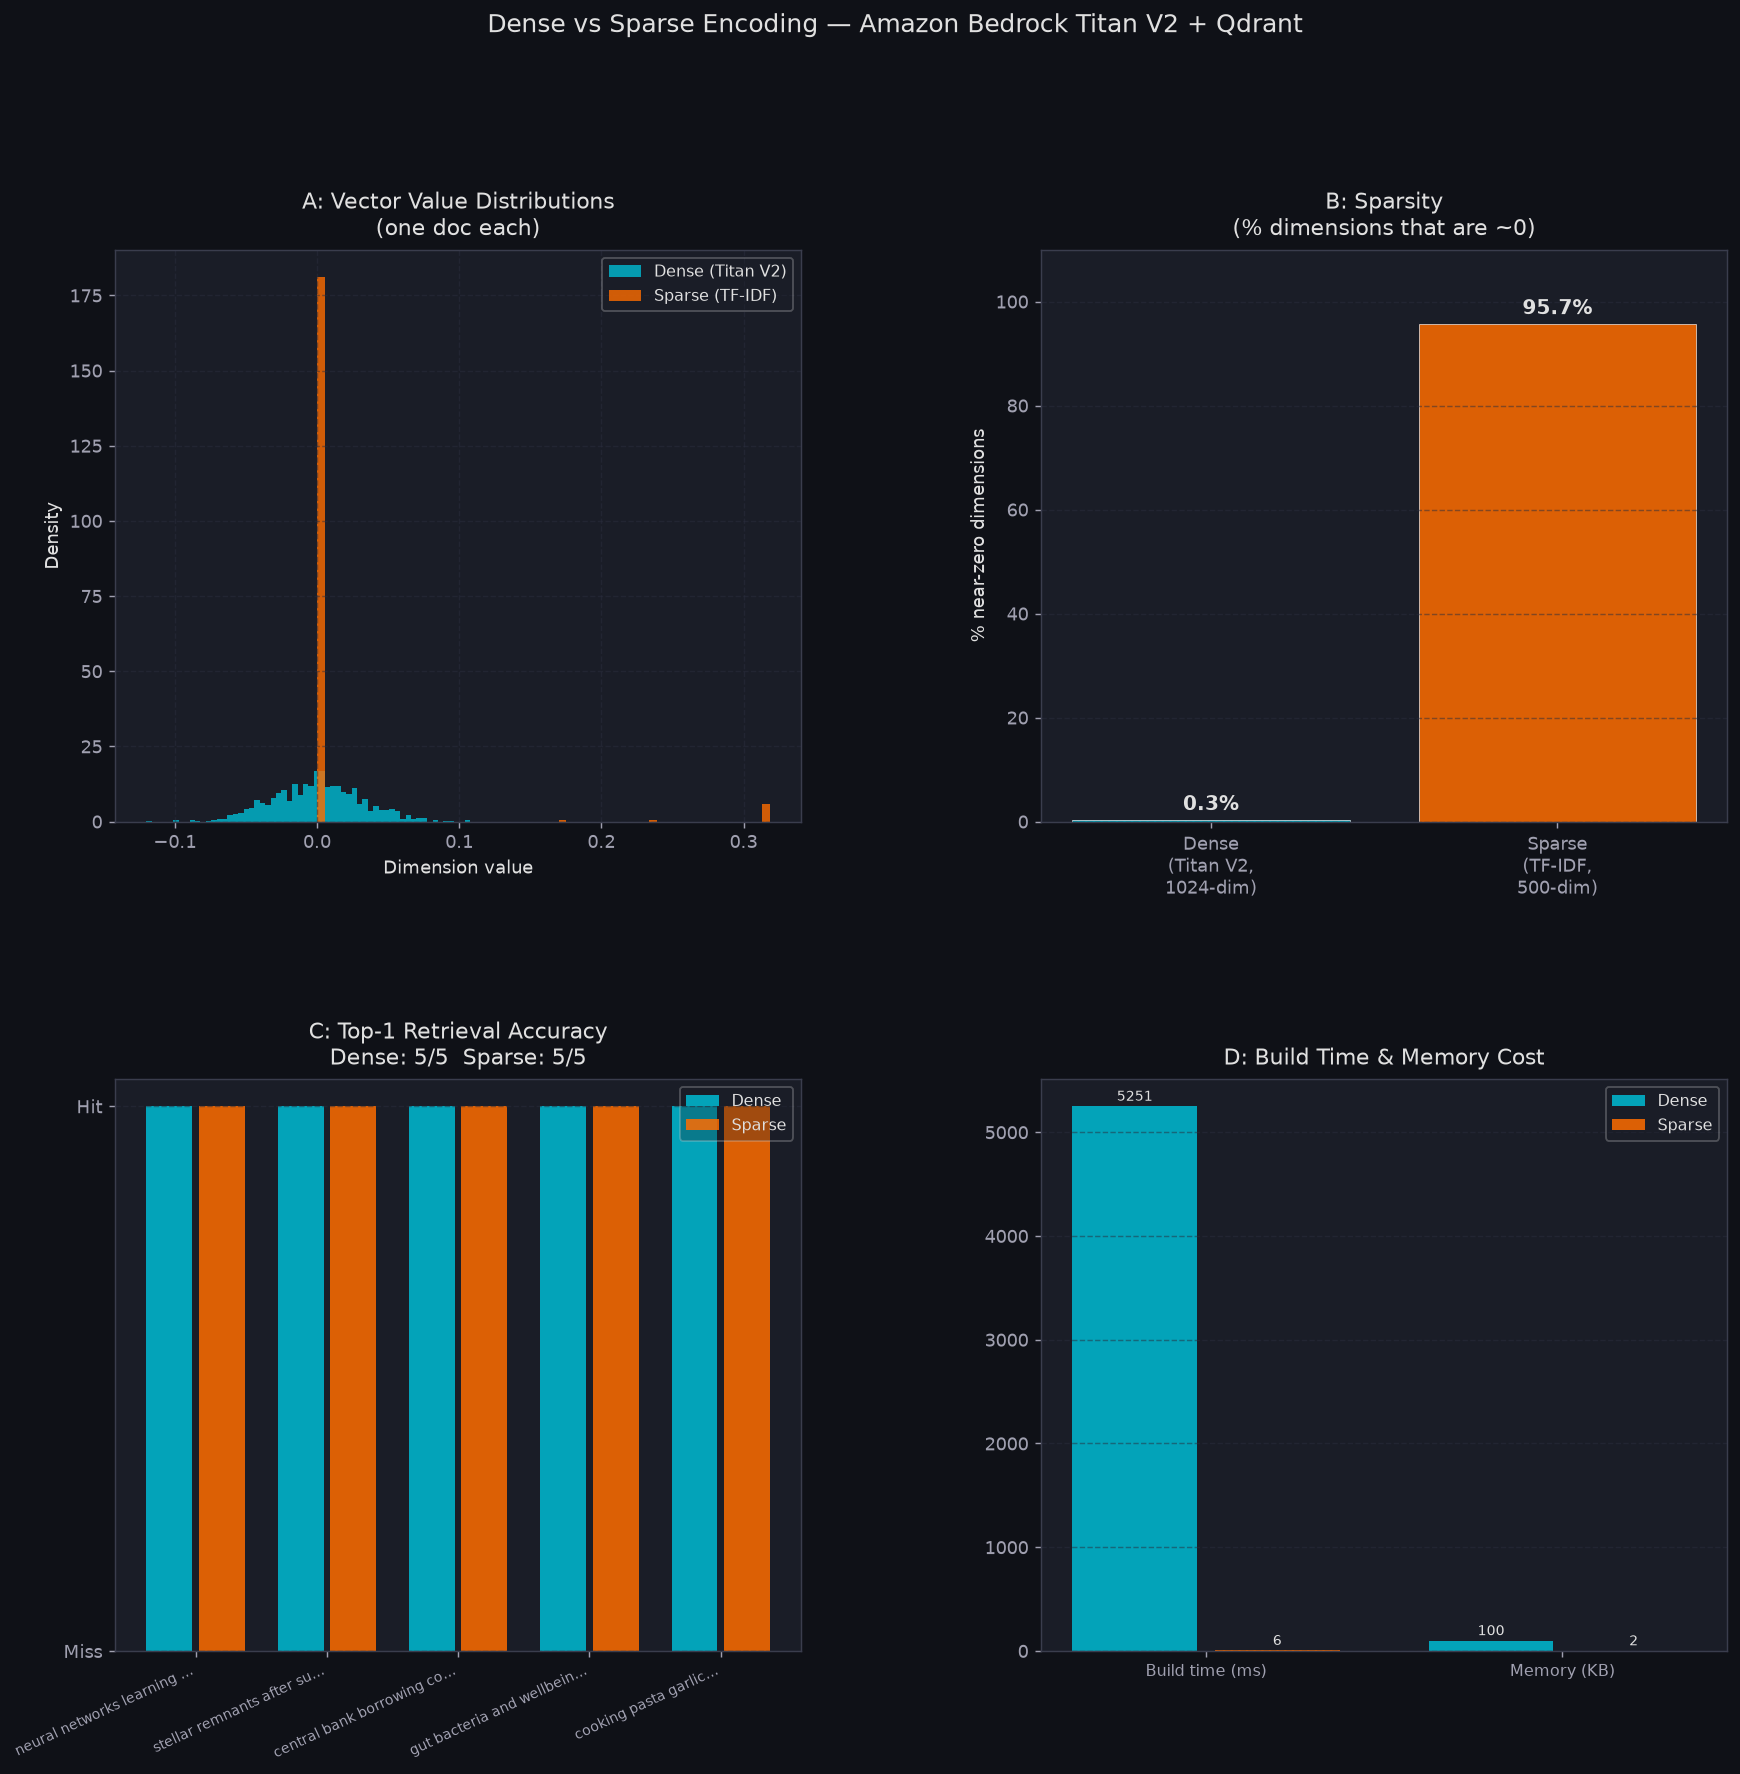

Saved: 02_dense_vs_sparse.png


In [10]:
fig = plt.figure(figsize=(16, 14), facecolor='#0f1117')
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# ── Plot A: Value distributions ───────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
sample_dense  = dense_matrix[0].flatten()
sample_sparse = sparse_matrix_dense[0].flatten()

ax_a.hist(sample_dense,  bins=60, color='#00BCD4', alpha=0.8, label='Dense (Titan V2)',  density=True)
ax_a.hist(sample_sparse, bins=60, color='#FF6D00', alpha=0.8, label='Sparse (TF-IDF)',   density=True)
ax_a.set_xlabel('Dimension value')
ax_a.set_ylabel('Density')
ax_a.set_title('A: Vector Value Distributions\n(one doc each)', pad=8)
ax_a.legend(framealpha=0.3, fontsize=9)
ax_a.grid(True)
ax_a.set_facecolor('#1a1d27')

# ── Plot B: Sparsity comparison ───────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
names  = ['Dense\n(Titan V2,\n1024-dim)', 'Sparse\n(TF-IDF,\n500-dim)']
spars  = [dense_sparsity, sparse_sparsity]
colors = ['#00BCD4', '#FF6D00']
bars   = ax_b.bar(names, spars, color=colors, alpha=0.85, edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, spars):
    ax_b.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%',
              ha='center', va='bottom', fontsize=11, fontweight='bold')
ax_b.set_ylabel('% near-zero dimensions')
ax_b.set_ylim(0, 110)
ax_b.set_title('B: Sparsity\n(% dimensions that are ~0)', pad=8)
ax_b.grid(axis='y')
ax_b.set_facecolor('#1a1d27')

# ── Plot C: Retrieval accuracy (top-1 topic match) ────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
q_labels   = [cd[0][:25]+'…' for cd in comparison_data]
dense_hits = [1 if cd[4]=='✓' else 0 for cd in comparison_data]
sparse_hits= [1 if cd[5]=='✓' else 0 for cd in comparison_data]
x = np.arange(len(q_labels))
ax_c.bar(x - 0.2, dense_hits,  0.35, label='Dense',  color='#00BCD4', alpha=0.85)
ax_c.bar(x + 0.2, sparse_hits, 0.35, label='Sparse', color='#FF6D00', alpha=0.85)
ax_c.set_xticks(x)
ax_c.set_xticklabels(q_labels, rotation=25, ha='right', fontsize=8)
ax_c.set_yticks([0, 1])
ax_c.set_yticklabels(['Miss', 'Hit'])
ax_c.set_title(f'C: Top-1 Retrieval Accuracy\nDense: {sum(dense_hits)}/{len(dense_hits)}  Sparse: {sum(sparse_hits)}/{len(sparse_hits)}', pad=8)
ax_c.legend(framealpha=0.3, fontsize=9)
ax_c.grid(axis='y')
ax_c.set_facecolor('#1a1d27')

# ── Plot D: Memory + build time ───────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
metrics = ['Build time (ms)', 'Memory (KB)']
dense_vals  = [dense_time * 1000,  dense_mem_bytes / 1024]
sparse_vals = [sparse_time * 1000, sparse_mem_bytes_approx / 1024]
x2 = np.arange(len(metrics))
ax_d.bar(x2 - 0.2, dense_vals,  0.35, label='Dense',  color='#00BCD4', alpha=0.85)
ax_d.bar(x2 + 0.2, sparse_vals, 0.35, label='Sparse', color='#FF6D00', alpha=0.85)
for xi, (dv, sv) in enumerate(zip(dense_vals, sparse_vals)):
    ax_d.text(xi - 0.2, dv + max(dense_vals+sparse_vals)*0.01, f'{dv:.0f}', ha='center', fontsize=8)
    ax_d.text(xi + 0.2, sv + max(dense_vals+sparse_vals)*0.01, f'{sv:.0f}', ha='center', fontsize=8)
ax_d.set_xticks(x2)
ax_d.set_xticklabels(metrics, fontsize=9)
ax_d.set_title('D: Build Time & Memory Cost', pad=8)
ax_d.legend(framealpha=0.3, fontsize=9)
ax_d.grid(axis='y')
ax_d.set_facecolor('#1a1d27')

fig.suptitle('Dense vs Sparse Encoding — Amazon Bedrock Titan V2 + Qdrant',
             fontsize=14, y=1.01, color='#e0e0e0')
plt.savefig('02_dense_vs_sparse.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: 02_dense_vs_sparse.png')

---
## NVIDIA Perspective — Dense vs Sparse Encoding

### NVIDIA's stance: GPU-accelerate dense, use BM25 as sparse baseline

NVIDIA's cuVS focuses entirely on **dense vector acceleration**. Sparse (BM25) is the CPU baseline they benchmark against.

### GPU speedups for dense search (DEEP-100M, H100)

| Metric | GPU gain over CPU |
|---|---|
| Index build time | **14×** faster (< 1 min for 100M vectors) |
| Search at 95% recall | **> 20×** faster |
| Index build cost (AWS) | **12.5×** cheaper |
| Throughput (10K batch) | **29×** higher |

### NVIDIA's own embedding model (dense, 1024-dim)
- Fine-tuned E5-Large-Unsupervised, 24 layers, **1024-dim** (same as Bedrock Titan V2)
- Highest Recall@5 across telco, IT, consulting, energy datasets
- Served via NIM: `llama-nemotron-embed-vl-1b-v2` with TensorRT-LLM

### Dense quantization tiers in cuVS

```
FP32 dense  ->  Binary       (4x  smaller, 4x  faster vs CPU)
            ->  Scalar INT8  (32x smaller, 20x faster vs CPU)
            ->  IVF-PQ       (variable: 1B vectors = 360 GiB -> 54 GiB)
```

**References:**
- [NVIDIA Retrieval QA Embedding Model](https://developer.nvidia.com/blog/build-enterprise-retrieval-augmented-generation-apps-with-nvidia-retrieval-qa-embedding-model/)
- [Accelerating Vector Search with RAFT](https://developer.nvidia.com/blog/accelerating-vector-search-using-gpu-powered-indexes-with-rapids-raft/)
- [IVF-Flat Deep Dive](https://developer.nvidia.com/blog/accelerated-vector-search-approximating-with-nvidia-cuvs-ivf-flat/)
- [NVIDIA NIM Embeddings](https://build.nvidia.com/explore/retrieval)


## Step 8 — Three Deeper Visualizations

### 8a · t-SNE Scatter — do dense embeddings form topic clusters?
### 8b · Sparse Fingerprint — what does a sparse vector actually look like?
### 8c · Paraphrase Robustness — when dense wins and when sparse wins

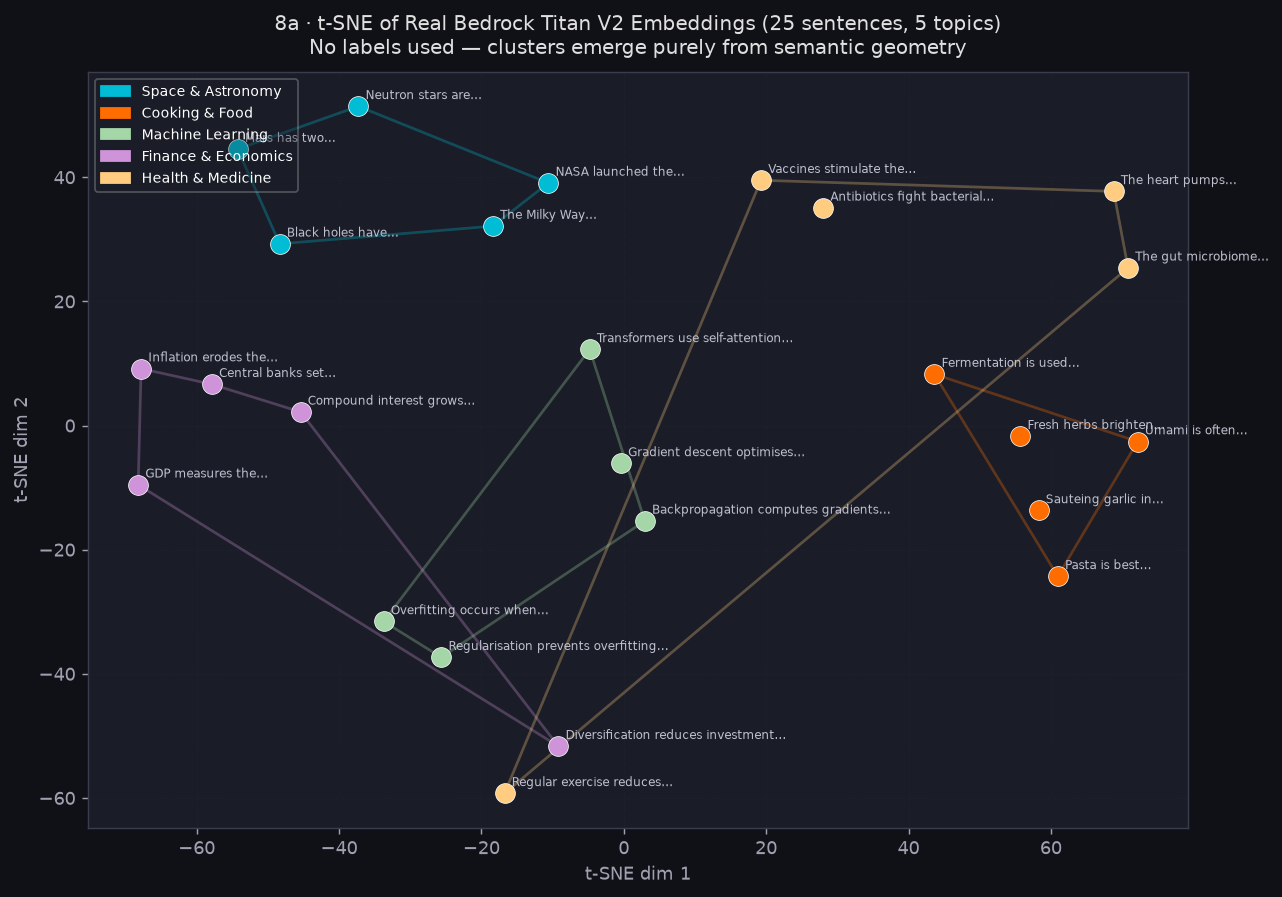

Saved: 02b_tsne_clusters.png


In [11]:
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches

# ── t-SNE on real Bedrock embeddings ─────────────────────────────────────────
tsne = TSNE(n_components=2, perplexity=5, max_iter=2000, random_state=42)
coords = tsne.fit_transform(dense_matrix)   # (25, 2)

topic_list = list(topic_sentences.keys())
palette = ['#00BCD4', '#FF6D00', '#A5D6A7', '#CE93D8', '#FFCC80']
topic_color = {t: palette[i] for i, t in enumerate(topic_list)}

fig, ax = plt.subplots(figsize=(10, 7), facecolor='#0f1117')
ax.set_facecolor('#1a1d27')

for i, (x, y) in enumerate(coords):
    color = topic_color[labels[i]]
    ax.scatter(x, y, color=color, s=120, zorder=3, edgecolors='white', linewidths=0.4)
    # short label: first 3 words
    short = ' '.join(sentences[i].split()[:3]) + '…'
    ax.annotate(short, (x, y), fontsize=6.5, color='#c0c0d0',
                xytext=(4, 4), textcoords='offset points')

# draw convex hull per topic to show clusters
from scipy.spatial import ConvexHull
for t, color in topic_color.items():
    pts = coords[[i for i, l in enumerate(labels) if l == t]]
    if len(pts) >= 3:
        hull = ConvexHull(pts)
        for simplex in hull.simplices:
            ax.plot(pts[simplex, 0], pts[simplex, 1], '-', color=color, alpha=0.3, lw=1.5)

legend_patches = [mpatches.Patch(color=topic_color[t], label=t) for t in topic_list]
ax.legend(handles=legend_patches, loc='upper left', fontsize=8,
          framealpha=0.3, labelcolor='white')
ax.set_title('8a · t-SNE of Real Bedrock Titan V2 Embeddings (25 sentences, 5 topics)\n'
             'No labels used — clusters emerge purely from semantic geometry',
             color='#e0e0e0', fontsize=11, pad=10)
ax.set_xlabel('t-SNE dim 1', color='#a0a0b0')
ax.set_ylabel('t-SNE dim 2', color='#a0a0b0')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('02b_tsne_clusters.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: 02b_tsne_clusters.png')

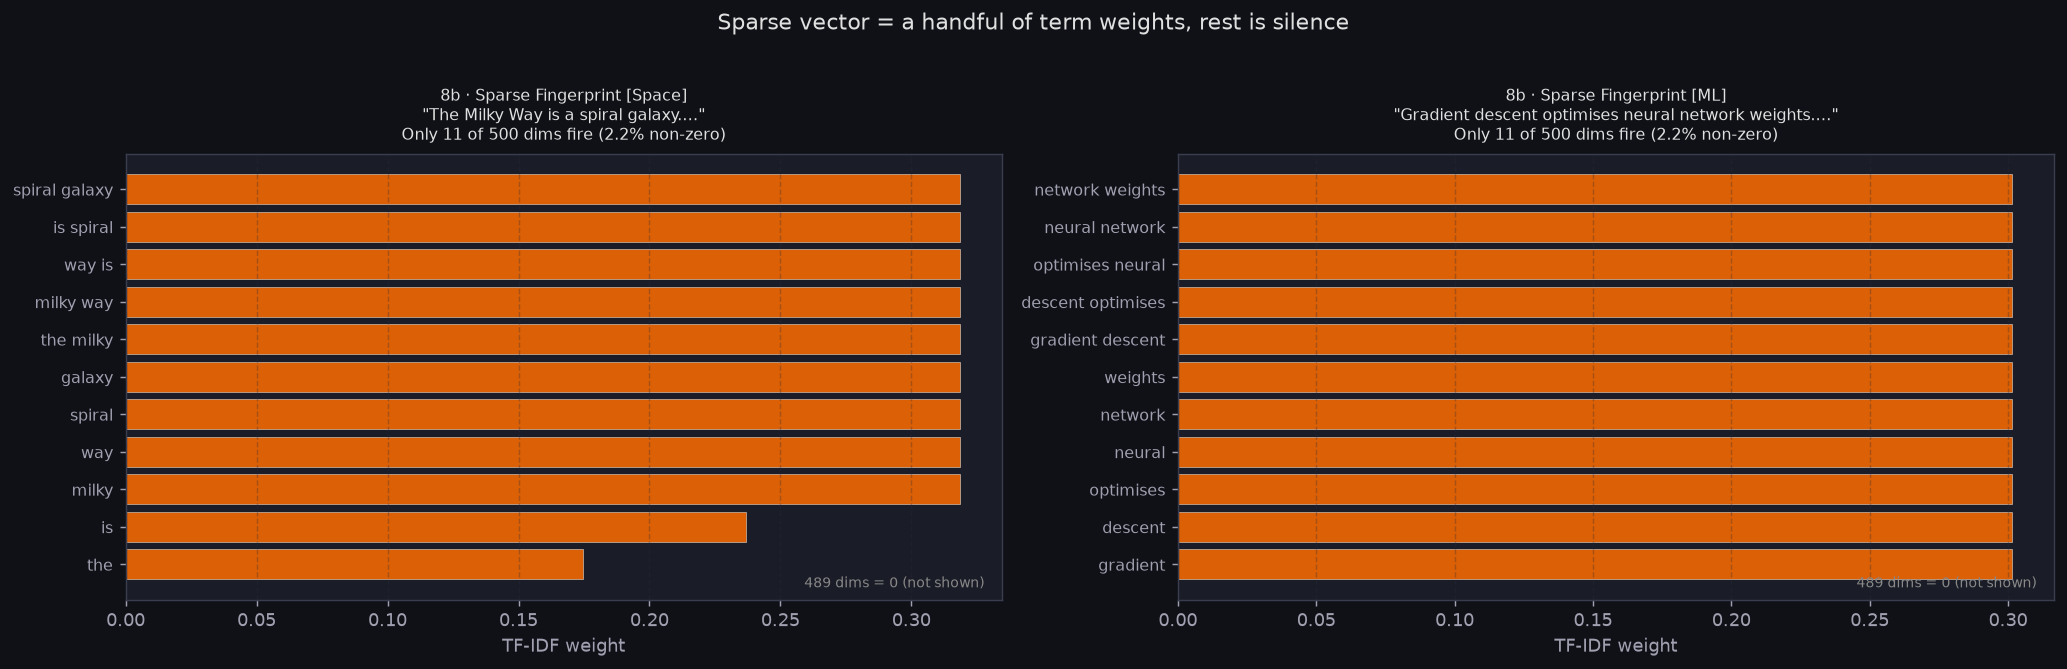

Saved: 02c_sparse_fingerprint.png


In [12]:
# ── Sparse fingerprint: what does a 500-dim sparse vector look like? ──────────
# Pick two contrasting sentences
EXAMPLES = [
    (0, 'Space'),       # 'The Milky Way is a spiral galaxy.'
    (10, 'ML'),         # 'Gradient descent optimises neural network weights.'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0f1117')
feature_names = tfidf.get_feature_names_out()

for ax, (sent_idx, label) in zip(axes, EXAMPLES):
    ax.set_facecolor('#1a1d27')
    row = sparse_matrix_csr[sent_idx]
    nz_idx = row.nonzero()[1]
    nz_val = row.data
    # sort by value desc, take top 12
    order = np.argsort(nz_val)[::-1][:12]
    terms  = feature_names[nz_idx[order]]
    values = nz_val[order]

    bars = ax.barh(range(len(terms)), values,
                   color='#FF6D00', alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.set_yticks(range(len(terms)))
    ax.set_yticklabels(terms, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('TF-IDF weight', color='#a0a0b0')
    ax.set_title(
        f'8b · Sparse Fingerprint [{label}]\n"{sentences[sent_idx][:55]}…"\n'
        f'Only {len(nz_idx)} of {SPARSE_DIM} dims fire ({len(nz_idx)/SPARSE_DIM*100:.1f}% non-zero)',
        color='#e0e0e0', fontsize=9, pad=8)
    ax.grid(axis='x', alpha=0.3)

    # annotate total zeros
    n_zero = SPARSE_DIM - len(nz_idx)
    ax.annotate(f'{n_zero} dims = 0 (not shown)',
                xy=(0.98, 0.02), xycoords='axes fraction',
                ha='right', va='bottom', fontsize=8, color='#888')

fig.suptitle('Sparse vector = a handful of term weights, rest is silence',
             fontsize=12, color='#e0e0e0', y=1.02)
plt.tight_layout()
plt.savefig('02c_sparse_fingerprint.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: 02c_sparse_fingerprint.png')

[paraphrase] D:✓ 0.459  S:✗ 0.302  Q: weight optimization algorithm deep learning


[paraphrase] D:✓ 0.426  S:✓ 0.431  Q: immune defence against disease pathogens


[keyword   ] D:✓ 0.696  S:✓ 0.853  Q: gradient descent neural network weights


[keyword   ] D:✓ 0.698  S:✓ 0.629  Q: vaccines immune system pathogens


[keyword   ] D:✓ 0.590  S:✓ 0.641  Q: purchasing power money inflation


[paraphrase] D:✓ 0.372  S:✗ 0.269  Q: economic value erosion currency devaluation


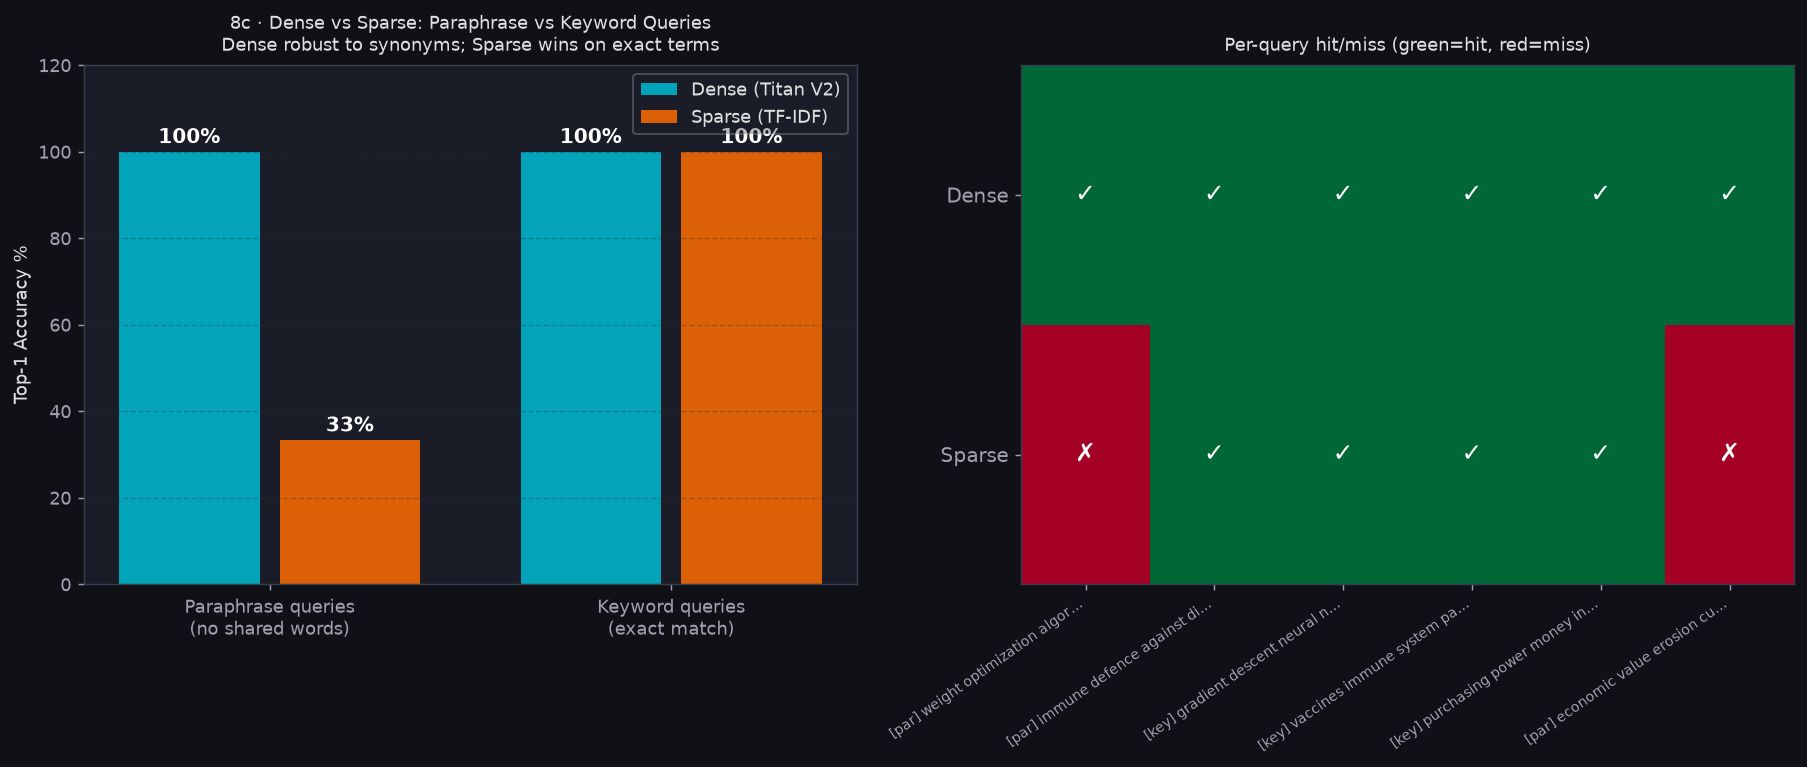

Saved: 02d_paraphrase_robustness.png


In [13]:
# ── Paraphrase robustness test ────────────────────────────────────────────────
# Dense should WIN on paraphrases (no shared words)
# Sparse should WIN on exact keyword matches

robustness_cases = [
    # (query,                                          ground_truth_sentence_idx, tag)
    ('weight optimization algorithm deep learning',   10, 'paraphrase'),  # GT: 'Gradient descent optimises neural network weights.'
    ('immune defence against disease pathogens',      20, 'paraphrase'),  # GT: 'Vaccines stimulate the immune system against pathogens.'
    ('gradient descent neural network weights',       10, 'keyword'),     # exact words
    ('vaccines immune system pathogens',              20, 'keyword'),     # exact words
    ('purchasing power money inflation',              15, 'keyword'),     # exact words
    ('economic value erosion currency devaluation',  15, 'paraphrase'),  # GT: 'Inflation erodes the purchasing power of money.'
]

gt_texts = [sentences[idx] for _, idx, _ in robustness_cases]

results = []
for query, gt_idx, tag in robustness_cases:
    # Dense
    qvec = embed(query)
    d_hits = qc.query_points(DENSE_COLL, query=qvec.tolist(), limit=3, with_payload=True).points
    d_top_text = d_hits[0].payload['text'] if d_hits else ''
    d_hit = d_top_text == sentences[gt_idx]
    d_score = float(d_hits[0].score) if d_hits else 0.0

    # Sparse
    qvec_sp = tfidf.transform([query])
    sp_idx = qvec_sp.nonzero()[1].tolist()
    sp_vals = qvec_sp.data.tolist()
    if sp_idx:
        s_hits = qc.query_points(SPARSE_COLL,
                     query=SparseVector(indices=sp_idx, values=sp_vals),
                     using='sparse', limit=3, with_payload=True).points
        s_top_text = s_hits[0].payload['text'] if s_hits else ''
        s_hit = s_top_text == sentences[gt_idx]
        s_score = float(s_hits[0].score) if s_hits else 0.0
    else:
        s_hit, s_score = False, 0.0

    results.append({'query': query, 'tag': tag, 'gt_idx': gt_idx,
                    'd_hit': d_hit, 'd_score': d_score,
                    's_hit': s_hit, 's_score': s_score})
    print(f'[{tag:10s}] D:{"✓" if d_hit else "✗"} {d_score:.3f}  '
          f'S:{"✓" if s_hit else "✗"} {s_score:.3f}  Q: {query[:50]}')

# ── grouped bar chart ─────────────────────────────────────────────────────────
paraphrase_rows = [r for r in results if r['tag'] == 'paraphrase']
keyword_rows    = [r for r in results if r['tag'] == 'keyword']

def accuracy(rows, key): return sum(r[key] for r in rows) / len(rows) * 100

cats   = ['Paraphrase queries\n(no shared words)', 'Keyword queries\n(exact match)']
d_acc  = [accuracy(paraphrase_rows,'d_hit'), accuracy(keyword_rows,'d_hit')]
s_acc  = [accuracy(paraphrase_rows,'s_hit'), accuracy(keyword_rows,'s_hit')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0f1117')

# left: accuracy bars
ax1.set_facecolor('#1a1d27')
x = np.arange(len(cats))
b1 = ax1.bar(x - 0.2, d_acc, 0.35, label='Dense (Titan V2)', color='#00BCD4', alpha=0.85)
b2 = ax1.bar(x + 0.2, s_acc, 0.35, label='Sparse (TF-IDF)',  color='#FF6D00', alpha=0.85)
for bar, val in zip(list(b1)+list(b2), d_acc+s_acc):
    ax1.text(bar.get_x()+bar.get_width()/2, val+2, f'{val:.0f}%',
             ha='center', fontsize=11, fontweight='bold', color='white')
ax1.set_xticks(x); ax1.set_xticklabels(cats, fontsize=10)
ax1.set_ylim(0, 120); ax1.set_ylabel('Top-1 Accuracy %')
ax1.set_title('8c · Dense vs Sparse: Paraphrase vs Keyword Queries\n'
              'Dense robust to synonyms; Sparse wins on exact terms',
              color='#e0e0e0', fontsize=10, pad=8)
ax1.legend(framealpha=0.3); ax1.grid(axis='y', alpha=0.3)

# right: per-query heatmap
ax2.set_facecolor('#1a1d27')
q_labels = [r['query'][:35]+'…' for r in results]
tags      = [r['tag'] for r in results]
d_hits_arr = np.array([[r['d_hit'] for r in results]])
s_hits_arr = np.array([[r['s_hit'] for r in results]])
combined   = np.vstack([d_hits_arr, s_hits_arr]).astype(float)  # (2, N)
im = ax2.imshow(combined, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax2.set_yticks([0,1]); ax2.set_yticklabels(['Dense','Sparse'], fontsize=11)
ax2.set_xticks(range(len(q_labels)))
ax2.set_xticklabels(
    [f'[{t[:3]}] {q[:25]}…' for t,q in zip(tags, [r["query"] for r in results])],
    rotation=35, ha='right', fontsize=7.5)
ax2.set_title('Per-query hit/miss (green=hit, red=miss)', color='#e0e0e0', fontsize=10, pad=8)
for row in range(2):
    for col in range(len(results)):
        val = combined[row, col]
        ax2.text(col, row, '✓' if val else '✗', ha='center', va='center',
                 fontsize=14, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('02d_paraphrase_robustness.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: 02d_paraphrase_robustness.png')

## Step 8 — Cleanup

In [14]:
qc.delete_collection(DENSE_COLL)
qc.delete_collection(SPARSE_COLL)
print('Collections deleted.')

Collections deleted.


## Summary — When to Use Which

| Scenario | Recommendation |
|----------|---------------|
| RAG / question-answering | **Dense** — deep semantics matter |
| Cross-lingual search | **Dense** — multilingual embedding models |
| Cost/latency critical | **Sparse** — 10× smaller, no RAM overhead |
| Keyword-heavy domains (codes, SKUs) | **Sparse** — falls back gracefully to BM25 |
| Best of both worlds | **Hybrid** — run both, normalize + combine scores |
| Need to explain results | **Sparse** — term weights are directly interpretable |

**Next notebook → 03_Hybrid_Search.ipynb** for combining both.